## 7.2HD


Training a model to perform binary classification from a dataset of real images and AI images, using Transfer Learning


Training a perceptron is computationally expensive, because the data is in RGB format total features in each image = 256 * 256 * 3 = 1,96,608 features for one image. That's alot of features for a perceptron to handle, we will be learning how to train a pre trained models from tensorflow 

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [2]:
datagen = ImageDataGenerator(
    rescale = 1./255, 
    validation_split = 0.2
)


train_gen = datagen.flow_from_directory(
    "D:/Deakin Workshops and PDF's/SIT753/7.3HD/archive/Dataset", 
    target_size = (224,224), 
    batch_size = 32, 
    class_mode = 'binary', 
    subset = 'training'
)

val_gen = datagen.flow_from_directory(
    "D:/Deakin Workshops and PDF's/SIT753/7.3HD/archive/Dataset", 
    target_size = (224,224), 
    batch_size = 32,
    class_mode = 'binary', 
    subset = "validation"
)


Found 777 images belonging to 2 classes.
Found 193 images belonging to 2 classes.


The MobileNetV2 model expects the image size to by 244 * 244 , that's around 59,000 features needed to train the model. 

Since the directory has 2 files under the dataset folder , AI images and real images, the flow_from_directory does the job of finding and labeling the images real: 1 and AI:0. and splits the dataset into training and validation. 

In [ ]:
#plugging the data into the pretrained MoblieNet model 

base = MobileNetV2(weights= 'imagenet', include_top=False, pooling = 'avg')
base.trainable = False

model = models.Sequential([
    base, 
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#training the model 



model.fit(
    train_gen, 
    validation_data = val_gen, 
    epochs = 5
)

C:\Users\moham\AppData\Local\Temp\ipykernel_21172\665170782.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights= 'imagenet', include_top=False, pooling = 'avg')


Epoch 1/5
11/25 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6107 - loss: 0.6844

d:\Anaconda\envs\myenv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.6242 - loss: 0.6620 - val_accuracy: 0.6114 - val_loss: 0.6558
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7169 - loss: 0.5428 - val_accuracy: 0.6839 - val_loss: 0.5983
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7825 - loss: 0.4810 - val_accuracy: 0.6995 - val_loss: 0.5761
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8121 - loss: 0.4420 - val_accuracy: 0.7098 - val_loss: 0.5488
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8327 - loss: 0.4066 - val_accuracy: 0.7150 - val_loss: 0.5365


In [4]:
history = model.fit(train_gen, validation_data=val_gen, epochs=5)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8468 - loss: 0.3843 - val_accuracy: 0.7202 - val_loss: 0.5325
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8610 - loss: 0.3661 - val_accuracy: 0.7254 - val_loss: 0.5276
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8700 - loss: 0.3471 - val_accuracy: 0.7358 - val_loss: 0.5255
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8906 - loss: 0.3296 - val_accuracy: 0.7358 - val_loss: 0.5210
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8855 - loss: 0.3176 - val_accuracy: 0.7358 - val_loss: 0.5213


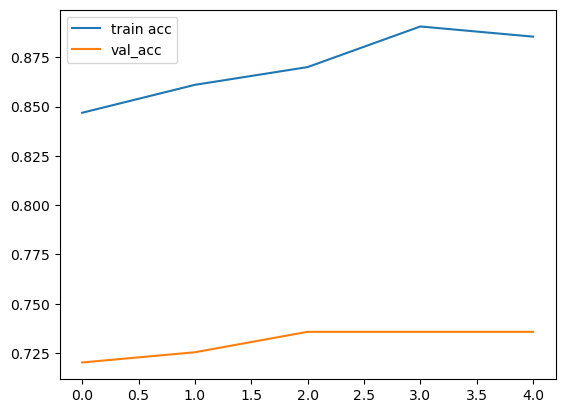

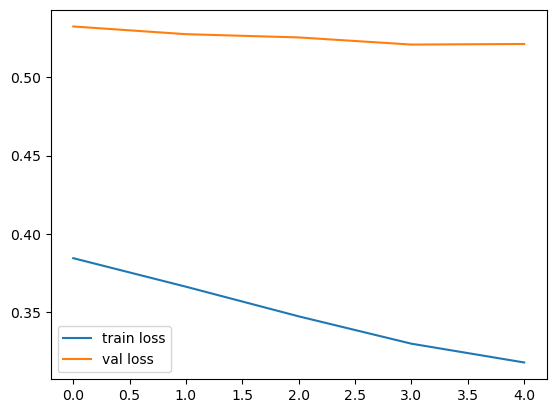

In [5]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label= 'val_acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.legend()
plt.show()

In [6]:
from tensorflow.keras.preprocessing import image
import numpy as np
def predict_img(img_path):
    img = image.load_img(img_path, target_size = (224,224))
    img_array = image.img_to_array(img)

    img_array = img_array/255.0

    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)[0][0] # 0,0 holds the model predictions 
    if pred > 0.5: 
        print(f"Prediction: REAL({pred})")
    else: 
        print(f"Prediction: AI Generated({pred})")

In [7]:
predict_img("D:/Deakin Workshops and PDF's/SIT753/7.3HD/person_studying_inlib.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: AI Generated(0.38914239406585693)


In [8]:
model.save("model.h5")

In [10]:
train_gen.classes
np.unique(train_gen.classes, return_counts=True)

(array([0, 1], dtype=int32), array([429, 348]))